# inference.ipynb — 저장된 모델로 2025년 발전량 예측 및 제출 파일 생성

## 이 노트북의 역할 (대회 2차 평가 산출물)

`train.ipynb`가 저장한 모델을 **불러오기만** 한다. **여기서는 어떤 학습도 하지 않는다.**

```
train.ipynb     : 피처 parquet -> LightGBM + MLP 학습 -> models/final/ 저장
inference.ipynb : models/final/ 로딩 -> test 예측 -> 블렌드 -> 제출 파일 + 검증
```

**두 파일이 어긋나지 않는 이유**

1. **전처리·피처**: `03_features.ipynb`가 train/test를 같은 함수로 만들어 parquet에 저장(A방식).
2. **신경망 구조·표준화**: `src/nn.py`를 양쪽이 import. 노트북에 복사하지 않는다.
3. **피처 순서와 모델 해시**: `config.json`에 저장해 두고 추론 시 대조한다.

## 최종 모델 구성

| | 모델 | 결합 |
|---|---|---|
| 모델 1 | LightGBM 분위수 회귀 (τ = 0.70 / 0.50 / 0.65, `actual` 가중) | 그룹별 가중 평균 |
| 모델 2 | MLP + 대회 산식 직접 최적화 손실 (시드 5개 평균) | `w` = 0.8 / 0.5 / 0.9 (MLP 비중) |

2024 홀드아웃 정직한 점수: **total 0.6458 | 1−NMAE 0.8744 | FICR 0.4172**

## 누수 방지 확인 (CLAUDE.md 4번)

- **test 기간(2025년) 데이터로 어떤 학습도 하지 않는다.**
- **표준화 통계(mu, sd)는 학습 데이터에서만 fit**한 값을 `scaler_{group}.npz`에서 읽어 **transform만** 한다.
- test 피처는 `03_features.ipynb`가 train과 완전히 같은 함수로 만들었다.
- 파워커브·풍속 보정식은 2022~2023 SCADA로만 fit되어 이미 피처 안에 반영되어 있다.
- **SCADA 실측치가 피처에 없음**을 아래에서 다시 assert로 확인한다.

## 제출 파일 규칙 (CLAUDE.md 7번)

`src/submission.py`의 `build_submission()`과 `validate_submission()`을 import해서 쓴다.
같은 로직을 이 노트북 셀에 복사하지 않는다.

## 0. 준비

In [1]:
import os, random, json, hashlib, platform, subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import torch

sys.path.insert(0, ".")
from src.metric import TARGET_COLS, CAPACITY_KWH
from src.submission import build_submission, save_submission, validate_submission, SUBMISSION_COLS
# 신경망 구조·표준화는 train.ipynb와 똑같은 것을 import한다 (복사 금지)
from src.nn import MLP, set_seed, predict_mlp

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RNG_SEED = 42
set_seed(RNG_SEED)          # 추론에는 난수가 쓰이지 않지만 환경을 학습과 동일하게 맞춘다
torch.set_num_threads(4)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = Path("models/final")
SUB_DIR = Path("submissions"); SUB_DIR.mkdir(exist_ok=True)
EXP_DIR = Path("experiments"); EXP_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

EXP_ID = "exp017"           # 이 제출의 실험 번호. 파일명·실험 로그와 일치시킨다

print(f"Python {platform.python_version()} | LightGBM {lgb.__version__} | PyTorch {torch.__version__}")

Python 3.13.14 | LightGBM 4.6.0 | PyTorch 2.13.0+cpu


## 1. 모델과 설정 로딩 — 무결성 확인

`config.json`에는 학습에 쓴 **피처 목록과 순서**, 각 모델 파일의 **sha256 해시**가 들어 있다.
LightGBM도 MLP도 컬럼 **이름이 아니라 위치**로 피처를 읽으므로, 순서가 다르면
**오류 없이 조용히 엉뚱한 예측**을 낸다. 그래서 여기서 대조해 다르면 즉시 멈춘다.

In [2]:
def sha256_of(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]


with open(MODEL_DIR / "config.json", encoding="utf-8") as fp:
    config = json.load(fp)

print(f"학습 시각 : {config['created']}")
print(f"git       : {config['git_hash']}")
print(f"모델      : {config['model']}")
print(f"피처      : {config['n_features']}개")
print(f"LightGBM τ: {config['group_tau']}")
print(f"블렌드 w  : {config['blend_w']}   (MLP 비중)")
print(f"MLP       : 시드 {config['nn_seeds']}, T_SOFT={config['t_soft']}")
print(f"학습 기간 : {config['train_period'][0]} ~ {config['train_period'][1]}")
print(f"학습 환경 : {config['versions']}")

FEATURE_COLS = config["feature_cols"]
BLEND_W = config["blend_w"]
NN_SEEDS = config["nn_seeds"]

boosters, mlps, scalers = {}, {}, {}
for g in TARGET_COLS:
    p = MODEL_DIR / f"lgbm_{g}.txt"
    assert sha256_of(p) == config["sha256"][f"lgbm_{g}"], f"{p} 해시 불일치 — train.ipynb를 다시 실행하세요"
    boosters[g] = lgb.Booster(model_file=str(p))

    sp = MODEL_DIR / f"scaler_{g}.npz"
    assert sha256_of(sp) == config["sha256"][f"scaler_{g}"], f"{sp} 해시 불일치"
    z = np.load(sp); scalers[g] = (z["mu"], z["sd"])

    mlps[g] = []
    for s in NN_SEEDS:
        mp = MODEL_DIR / f"mlp_{g}_seed{s}.pt"
        assert sha256_of(mp) == config["sha256"][f"mlp_{g}_seed{s}"], f"{mp} 해시 불일치"
        m = MLP(len(FEATURE_COLS))
        m.load_state_dict(torch.load(mp, weights_only=True))
        m.eval()
        mlps[g].append(m)
    print(f"\n{g}: LightGBM {boosters[g].num_trees()}그루 + MLP {len(mlps[g])}개 로딩 ✔ (해시 일치)")

for lib, cur in [("lightgbm", lgb.__version__), ("torch", torch.__version__)]:
    if cur != config["versions"][lib]:
        print(f"\n⚠ {lib} 버전이 학습 때({config['versions'][lib]})와 다릅니다 (현재 {cur})")

학습 시각 : 2026-07-10 13:38:25
git       : 4248c9a(dirty)
모델      : blend(lightgbm_quantile, mlp_metric_loss)
피처      : 179개
LightGBM τ: {'kpx_group_1': 0.7, 'kpx_group_2': 0.5, 'kpx_group_3': 0.65}
블렌드 w  : {'kpx_group_1': 0.8, 'kpx_group_2': 0.5, 'kpx_group_3': 0.9}   (MLP 비중)
MLP       : 시드 [42, 1337, 2024, 7, 99], T_SOFT=0.006
학습 기간 : 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
학습 환경 : {'python': '3.13.14', 'lightgbm': '4.6.0', 'torch': '2.13.0+cpu', 'numpy': '2.5.1', 'pandas': '3.0.3', 'os': 'Windows-11-10.0.26200-SP0'}

kpx_group_1: LightGBM 112그루 + MLP 5개 로딩 ✔ (해시 일치)

kpx_group_2: LightGBM 198그루 + MLP 5개 로딩 ✔ (해시 일치)

kpx_group_3: LightGBM 110그루 + MLP 5개 로딩 ✔ (해시 일치)


## 2. test 피처 로딩과 검증

In [3]:
feat_test = pd.read_parquet(PROCESSED_DIR / "features_test.parquet")
N_TEST_HOURS = 8760

assert len(feat_test) == N_TEST_HOURS, f"test 행 수가 {len(feat_test)}개입니다 (기대: {N_TEST_HOURS})"
test_cols = [c for c in feat_test.columns if c != "forecast_kst_dtm"]
assert test_cols == FEATURE_COLS, (
    "test 피처의 이름/순서가 학습 때와 다릅니다.\n"
    f"  학습에만 있음: {set(FEATURE_COLS) - set(test_cols)}\n"
    f"  test에만 있음: {set(test_cols) - set(FEATURE_COLS)}\n"
    "  (집합이 같은데 실패했다면 '순서'가 다른 것입니다)")
assert feat_test[FEATURE_COLS].isna().sum().sum() == 0, "test 피처에 결측이 있습니다"
assert not np.isinf(feat_test[FEATURE_COLS].to_numpy()).any(), "test 피처에 무한대가 있습니다"
assert feat_test["forecast_kst_dtm"].is_monotonic_increasing
assert not feat_test["forecast_kst_dtm"].duplicated().any()

# 누수 재점검: SCADA 실측치나 라벨이 test 피처에 섞여 있지 않은지
leaked = [c for c in test_cols if c.startswith("scada_") or c in TARGET_COLS]
assert not leaked, f"test 피처에 있으면 안 되는 컬럼: {leaked}"

print(f"features_test.parquet: {feat_test.shape} ✔")
print(f"기간: {feat_test['forecast_kst_dtm'].min()} ~ {feat_test['forecast_kst_dtm'].max()}")
print(f"피처 {len(FEATURE_COLS)}개, 이름·순서 학습과 일치 ✔ | 누수 컬럼 없음 ✔")

features_test.parquet: (8760, 180) ✔
기간: 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00
피처 179개, 이름·순서 학습과 일치 ✔ | 누수 컬럼 없음 ✔


## 3. 예측과 블렌드

두 모델로 각각 예측한 뒤 **그룹별 가중치**로 섞는다.

```
최종 예측 = (1 - w) × LightGBM + w × MLP
w = 0.8 / 0.5 / 0.9  (그룹 1 / 2 / 3)
```

`total_score = 그룹별 점수의 단순 평균`이라는 항등식(`src/metric.py`의 `group_score()`) 덕분에
그룹마다 다른 `w`를 써도 전체 점수를 정확히 최적화한다.

마지막으로 `clip(0, 설비용량)`을 적용한다. MLP는 sigmoid 출력이라 애초에 범위를 벗어나지 않지만,
LightGBM은 벗어날 수 있다.

In [4]:
X_test = feat_test[FEATURE_COLS].to_numpy(np.float32)

preds = {}
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    p_lgb = boosters[g].predict(feat_test[FEATURE_COLS])
    n_neg, n_over = int((p_lgb < 0).sum()), int((p_lgb > cap).sum())
    p_lgb = np.clip(p_lgb, 0, cap)

    mu, sd = scalers[g]
    p_mlp = np.mean([predict_mlp(m, X_test, mu, sd, cap) for m in mlps[g]], axis=0)

    w = BLEND_W[g]
    preds[g] = np.clip((1 - w) * p_lgb + w * p_mlp, 0, cap)
    print(f"{g}: w={w:.1f} | LightGBM 평균 {p_lgb.mean():>8,.0f} kWh (음수 clip {n_neg}, 초과 clip {n_over}) "
          f"| MLP 평균 {p_mlp.mean():>8,.0f} | 블렌드 {preds[g].mean():>8,.0f}")

pred_df = pd.DataFrame({"forecast_kst_dtm": feat_test["forecast_kst_dtm"], **preds})
print(f"\npred_df: {pred_df.shape}")
pred_df.head(3)

kpx_group_1: w=0.8 | LightGBM 평균   10,420 kWh (음수 clip 0, 초과 clip 0) | MLP 평균    9,046 | 블렌드    9,321
kpx_group_2: w=0.5 | LightGBM 평균    9,300 kWh (음수 clip 10, 초과 clip 0) | MLP 평균    9,585 | 블렌드    9,443


kpx_group_3: w=0.9 | LightGBM 평균    8,879 kWh (음수 clip 0, 초과 clip 0) | MLP 평균    8,145 | 블렌드    8,218

pred_df: (8760, 4)


,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,2025-01-01 01:00:00,19214.728624,19990.133842,16981.155080
1,2025-01-01 02:00:00,18629.343509,19415.777899,16794.870850
2,2025-01-01 03:00:00,18671.741398,19491.252728,17184.808667


### 3-1. 예측값이 상식적인가 — 제출 전 마지막 눈검사

정답이 없으므로 점수를 낼 수 없다. 대신 **분포가 학습 기간과 어긋나지 않는지**만 본다.
크게 어긋난다면 피처가 잘못 붙었거나 모델이 잘못 로딩된 것이다.

**예측 평균이 실제 평균보다 높은 것은 정상이다.** 두 가지가 겹친 결과다.

1. LightGBM: `actual` 가중 + τ>0.5 → 위로 편향 (`phase4_tuning.md` §1-2)
2. MLP: **채점 대상 행만** 학습 → "모든 시간이 채점 대상이라면 얼마?"를 예측

산식이 `valid = actual >= capacity * 0.10`으로 걸러내므로, 저풍속 시간을 크게 틀려도 벌점이 없다.

         그룹  실제 평균 이용률 (전체)  실제 평균 (채점 대상만)  물리예측 2025 평균  모델예측 2025 평균  예측 최소  예측 최대
kpx_group_1          0.3066          0.4890        0.3382        0.4315 0.0788 0.9675
kpx_group_2          0.3276          0.5245        0.3818        0.4372 0.0343 0.9666
kpx_group_3          0.2649          0.4754        0.3210        0.3913 0.0696 0.9390



'모델예측 평균'이 '실제 평균(채점 대상만)'과 비슷하면 의도대로 작동하는 것이다.


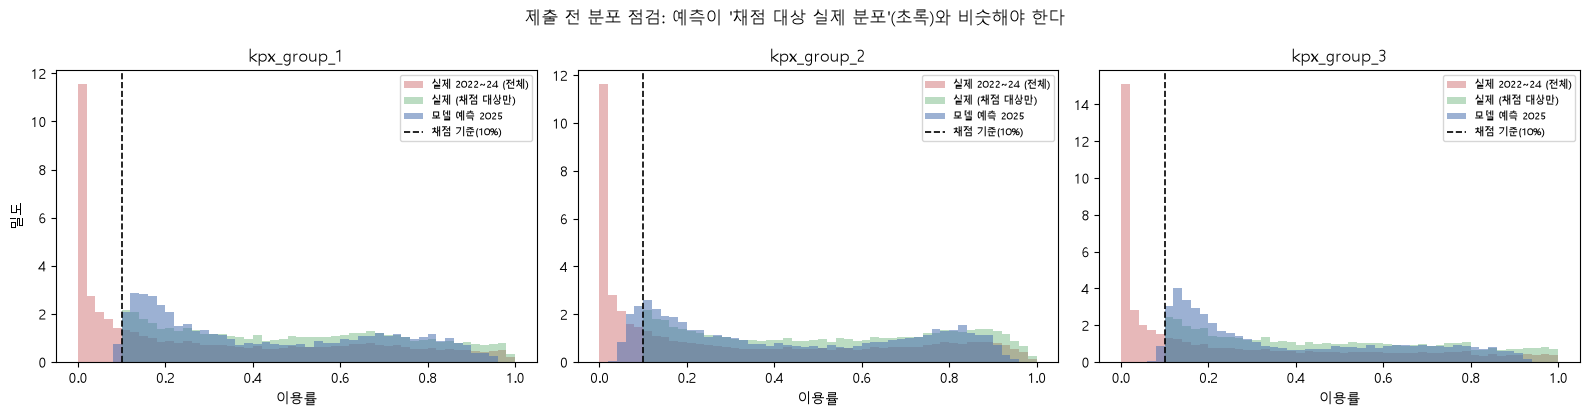

In [5]:
feat_train = pd.read_parquet(PROCESSED_DIR / "features_train.parquet")

rows = []
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    lab = feat_train[g].dropna() / cap
    scored = lab[lab >= 0.10]
    rows.append({"그룹": g,
                 "실제 평균 이용률 (전체)": lab.mean(),
                 "실제 평균 (채점 대상만)": scored.mean(),
                 "물리예측 2025 평균": (feat_test[f"pc_pred_{g}"] / cap).mean(),
                 "모델예측 2025 평균": (preds[g] / cap).mean(),
                 "예측 최소": (preds[g] / cap).min(), "예측 최대": (preds[g] / cap).max()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n'모델예측 평균'이 '실제 평균(채점 대상만)'과 비슷하면 의도대로 작동하는 것이다.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, g in zip(axes, TARGET_COLS):
    cap = CAPACITY_KWH[g]
    bins = np.linspace(0, 1, 51)
    ax.hist((feat_train[g] / cap).dropna(), bins=bins, alpha=0.40, density=True,
            label="실제 2022~24 (전체)", color="#C44E52")
    lab = (feat_train[g] / cap).dropna()
    ax.hist(lab[lab >= 0.10], bins=bins, alpha=0.40, density=True,
            label="실제 (채점 대상만)", color="#55A868")
    ax.hist(preds[g] / cap, bins=bins, alpha=0.55, density=True, label="모델 예측 2025", color="#4C72B0")
    ax.axvline(0.10, color="black", ls="--", lw=1.2, label="채점 기준(10%)")
    ax.set_xlabel("이용률"); ax.set_title(g); ax.legend(fontsize=7)
axes[0].set_ylabel("밀도")
fig.suptitle("제출 전 분포 점검: 예측이 '채점 대상 실제 분포'(초록)와 비슷해야 한다")
fig.tight_layout(); fig.savefig(FIG_DIR / "phase6_prediction_distribution.png", dpi=120); plt.show()

## 4. 제출 파일 생성과 검증

`sample_submission.csv`를 그대로 읽어 예측값 3개 컬럼만 덮어쓴다.
시각 매칭은 문자열이 아니라 **datetime으로 파싱해 merge**한다 (`src/submission.py`).

In [6]:
sample = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig")
submission = build_submission(pred_df, dtm_col="forecast_kst_dtm", sample_df=sample)
out_path = SUB_DIR / f"submission_{EXP_ID}.csv"
save_submission(submission, str(out_path))
print(f"저장: {out_path} ({out_path.stat().st_size/1e3:.1f} KB)")

issues = validate_submission(str(out_path), sample_df=sample, raise_on_error=True)
print("제출 파일 검증 통과 ✔ (문제 0건)")

check = pd.read_csv(out_path, encoding="utf-8-sig")
print(f"\n행 {len(check):,} | 컬럼 {check.columns.tolist()}")
print(f"첫 행: {check.iloc[0]['forecast_kst_dtm']} | 마지막 행: {check.iloc[-1]['forecast_kst_dtm']}")
print("\n예측값 요약 (kWh):")
print(check[TARGET_COLS].describe().T[["mean", "min", "max"]].to_string(float_format=lambda x: f"{x:,.1f}"))
for g in TARGET_COLS:
    assert check[g].between(0, CAPACITY_KWH[g]).all()
print("\n모든 값이 [0, 설비용량] 범위 안 ✔")

# 이전 제출(exp016, LightGBM 단독)과 얼마나 달라졌는지
prev = SUB_DIR / "submission_exp016.csv"
if prev.exists():
    old = pd.read_csv(prev, encoding="utf-8-sig")
    print("\n[exp016(LightGBM 단독) 대비 예측 변화]")
    for g in TARGET_COLS:
        d = (check[g] - old[g]) / CAPACITY_KWH[g]
        print(f"  {g}: 평균 {d.mean():+.4f}, 절대차 평균 {d.abs().mean():.4f} (설비용량 대비)")

저장: submissions\submission_exp017.csv (791.0 KB)
제출 파일 검증 통과 ✔ (문제 0건)

행 8,760 | 컬럼 ['forecast_id', 'forecast_kst_dtm', 'kpx_group_1', 'kpx_group_2', 'kpx_group_3']
첫 행: 2025-01-01 01:00:00 | 마지막 행: 2026-01-01 00:00:00

예측값 요약 (kWh):
               mean     min      max
kpx_group_1 9,320.9 1,702.5 20,898.5
kpx_group_2 9,442.8   740.2 20,877.7
kpx_group_3 8,218.0 1,462.6 19,719.3

모든 값이 [0, 설비용량] 범위 안 ✔

[exp016(LightGBM 단독) 대비 예측 변화]
  kpx_group_1: 평균 -0.0509, 절대차 평균 0.0570 (설비용량 대비)
  kpx_group_2: 평균 +0.0066, 절대차 평균 0.0238 (설비용량 대비)
  kpx_group_3: 평균 -0.0315, 절대차 평균 0.0477 (설비용량 대비)


## 5. 실험 로그 기록

`public_score`는 리더보드 제출 후 손으로 채운다.
**Public은 오프셋을 재는 용도이지 튜닝 대상이 아니다** (CLAUDE.md 5번).

In [7]:
def git_state():
    try:
        h = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
        d = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip()
        return f"{h}({'dirty' if d else 'clean'})"
    except Exception:
        return "unknown"


log_path = EXP_DIR / "log.csv"
prev_log = pd.read_csv(log_path, encoding="utf-8-sig") if log_path.exists() else pd.DataFrame()
if len(prev_log) and "exp_id" in prev_log.columns:
    prev_log = prev_log[prev_log["exp_id"] != EXP_ID].reset_index(drop=True)   # 재실행해도 중복 없게

h = config["holdout_score_2024"]
row = {"exp_id": EXP_ID, "date": pd.Timestamp.today().strftime("%Y-%m-%d"), "git_hash": git_state(),
       "model": "FINAL blend(lightgbm_quantile + mlp_metric_loss)",
       "features": f"v1_{config['n_features']}feat",
       "total_score": h["total"], "one_minus_nmae": h["one_minus_nmae"], "ficr": h["ficr"],
       "nmae_g1": "", "nmae_g2": "", "nmae_g3": "", "ficr_g1": "", "ficr_g2": "", "ficr_g3": "",
       "val_period": "2024 홀드아웃(학습 제외 시). 최종 모델은 2022~2024 전체 학습",
       "fit_seconds": "", "public_score": "",
       "note": f"제출 {out_path.name} | blend_w={config['blend_w']} | T_SOFT={config['t_soft']} "
               f"| MLP 시드{len(NN_SEEDS)}평균 | exp016(LGB단독) 대비 홀드아웃 +0.0151"}
log_df = pd.concat([prev_log, pd.DataFrame([row])], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")
print(f"저장: {log_path} (총 {len(log_df)}행)")

print(f"\n{'='*88}")
print(f"제출 파일: {out_path}")
print(f"로컬 2024 홀드아웃: total {h['total']:.4f} (1-NMAE {h['one_minus_nmae']:.4f}, FICR {h['ficr']:.4f})")
print(f"이전 제출 exp016: 홀드아웃 0.6308 -> Public 0.62284 (오프셋 -0.0079)")
print(f"exp017 Public 예상: 약 {h['total'] - 0.0079:.4f} (오프셋이 같다면)")
print()
print("다음에 할 일:")
print(f"  1) {out_path} 를 DACON에 제출 (하루 5회 제한)")
print(f"  2) 받은 Public 점수를 experiments/log.csv의 {EXP_ID} 행 public_score 칸에 기록")
print("  3) 오프셋(Public - 0.6458)이 exp016의 -0.0079와 비슷한지 확인")
print(f"{'='*88}")

저장: experiments\log.csv (총 17행)

제출 파일: submissions\submission_exp017.csv
로컬 2024 홀드아웃: total 0.6458 (1-NMAE 0.8744, FICR 0.4172)
이전 제출 exp016: 홀드아웃 0.6308 -> Public 0.62284 (오프셋 -0.0079)
exp017 Public 예상: 약 0.6379 (오프셋이 같다면)

다음에 할 일:
  1) submissions\submission_exp017.csv 를 DACON에 제출 (하루 5회 제한)
  2) 받은 Public 점수를 experiments/log.csv의 exp017 행 public_score 칸에 기록
  3) 오프셋(Public - 0.6458)이 exp016의 -0.0079와 비슷한지 확인
